In [1]:
import os
import sys
sys.path.insert(0, '/Users/ychao/Documents/develops/ase/')
import glob
import numpy as np
from ase import Atom, Atoms
from ase.io import read, write
from ase.db import connect
from ase.geometry import get_layers, get_distances
from ase.build import surface
from ase.build.surfaces_with_termination import surfaces_with_termination
from ase.constraints import FixAtoms
from ase.visualize import view
from ase.data import covalent_radii, atomic_numbers
from ase.dev.nsurface import align_zdir
from matplotlib import pyplot as plt

from utilize import calc_angle, rand_direction, BLDA_vector, grow_atom_BLDA, fix_layer
from plot_config import _plotting_config, writefig, clrs

In [2]:
def plot_usout(dirname, figname):
    _plotting_config(width=12, hegith=6, fsize=16)
    usout_list = glob.glob(dirname + 'usoutput_*')
    for usout in usout_list:
        data = np.loadtxt(usout, skiprows=6).T
        plt.hist(data, bins=100, density=True)
        counts, bin_edges = np.histogram(data, bins=20, density=True)
        bin_centers = 0.5 * (bin_edges[1:] + bin_edges[:-1])
        plt.plot(bin_centers, counts, linestyle='-', color='k')
    plt.xlabel('Reaction coordinate (Å)')
    plt.ylabel('Probability density')
    writefig(figname)
    
def read_fep(fname):
    with open(fname, 'r') as f:
        lines = f.readlines()
        read_flag = False
        fep = []
        for line in lines:
            if 'Window' in line:
                read_flag = True
            if read_flag:
                fep.append(line.split()[1])

    fep = np.array(fep[1:], dtype=float)
    return fep

## Read the initial bulk structure

In [6]:
bulk = read('../test_lasp/bulk/RuO2.poscar') 

## Generate the simplest surface model

In [7]:
surf = surfaces_with_termination(bulk, (1, 1, 0), layers=4, vacuum=10, termination='O')
[align_zdir(atom) for atom in surf]
surf_1 = surfaces_with_termination(bulk, (1, 0, 0), layers=2, vacuum=10, termination='O')
[align_zdir(atom) for atom in surf_1]
surf_2 = surfaces_with_termination(bulk, (1, 1, 1), layers=4, vacuum=10, termination='O')
[align_zdir(atom) for atom in surf_2]
surf_3 = surfaces_with_termination(bulk, (1, 0, 1), layers=4, vacuum=10, termination='O')
[align_zdir(atom) for atom in surf_3]
surf_4 = surfaces_with_termination(bulk, (0, 1, 1), layers=4, vacuum=10, termination='O')
[align_zdir(atom) for atom in surf_4]

[Atoms(symbols='Ru2O4Ru2O4Ru2O4Ru2O4', pbc=[True, True, False], cell=[[4.482500315, 0.0, 0.0], [4.917674613704964e-16, 5.456487366550853, 0.0], [0.0, 0.0, 29.443159225246248]], tags=...),
 Atoms(symbols='Ru2O4Ru2O4Ru2O4Ru2O4', pbc=[True, True, False], cell=[[4.482500315, 0.0, 0.0], [4.917674613704964e-16, 5.456487366550853, 0.0], [0.0, 0.0, 29.229292666238248]], tags=...),
 Atoms(symbols='Ru2O4Ru2O4Ru2O4Ru2O4', pbc=[True, True, False], cell=[[4.482500315, 0.0, 0.0], [4.917674613704964e-16, 5.456487366550853, 0.0], [0.0, 0.0, 29.229292666238244]], tags=...),
 Atoms(symbols='Ru2O4Ru2O4Ru2O4Ru2O4', pbc=[True, True, False], cell=[[4.482500315, 0.0, 0.0], [4.917674613704964e-16, 5.456487366550853, 0.0], [0.0, 0.0, 29.443159225246248]], tags=...)]

## Elementary opperation on the surface model (repeat, fixed)

### Repeat

In [8]:
view([s.repeat((3,3,1)) for s in surf_4])

<Popen: returncode: None args: ['/Users/ychao/Documents/conda/env/ase/bin/py...>

2024-11-26 15:22:54.498 python[48635:4038014] +[IMKClient subclass]: chose IMKClient_Modern
2024-11-26 15:22:54.498 python[48635:4038014] +[IMKInputSession subclass]: chose IMKInputSession_Modern


In [5]:
surf_O_Ru = surf[0]
surf_O_Ru_1 = surf_1[0]
surf_O_Ru_2 = surf_2[1]
surf_O_Ru_3 = surf_3[1]
surf_O_Ru_4 = surf_4[2]

#surf_O_Ru = surf[0]
#view(surf_O_Ru)
#write('surf_O_Ru_231.vasp', surf_O_Ru.repeat((2, 3, 1)))

NameError: name 'surf' is not defined

### Fix

In [6]:
def fix_layer(surf, fix_layer, miller=(0, 0, 1)):
    layer_index, dis_list = get_layers(surf, miller)
    n_layer = len(set(layer_index))
    c = FixAtoms(indices=np.argwhere(layer_index < fix_layer).flatten())
    tmp = surf.copy()
    tmp.set_constraint(c)
    return tmp

In [46]:
fix_surf.repeat((2, 3, 1))


Atoms(symbols='O96Ru48', pbc=True, cell=[[8.96500063, 0.0, 0.0], [1.475302384111489e-15, 16.36946209965256, 0.0], [0.0, 0.0, 29.229292666238244]], tags=..., constraint=FixAtoms(indices=[0, 1, 2, 3, 4, 5, 6, 7, 8, 9, 10, 11, 24, 25, 26, 27, 28, 29, 30, 31, 32, 33, 34, 35, 48, 49, 50, 51, 52, 53, 54, 55, 56, 57, 58, 59, 72, 73, 74, 75, 76, 77, 78, 79, 80, 81, 82, 83, 96, 97, 98, 99, 100, 101, 102, 103, 104, 105, 106, 107, 120, 121, 122, 123, 124, 125, 126, 127, 128, 129, 130, 131]))

In [86]:
from candidates import Candidate
db = connect('./test/dateset/candidates_surf.db')
miller_list = [110, 100, 111, 101]
for k,s  in enumerate([surf_O_Ru, surf_O_Ru_1, surf_O_Ru_2, surf_O_Ru_3]):
    fix_surf = fix_layer(s, 6)
    fix_surf.set_pbc((True, True, True))
    for i in range(1, 5):
        for j in range(1, 5):
            new_surf = fix_surf.copy()
            # new_surf.repeat((i, j, 1))
            cand = Candidate(new_surf.repeat((i, j, 1)))
            cand.add_metadata('surface', '%dx%d'%(i, j))
            db.write(cand, species='RuO2', miller=miller_list[k],data=cand.metadata)




In [40]:
fix_surf = fix_layer(surf_O_Ru_4, 6)
fix_surf.set_pbc([True, True, True])
view(fix_surf)
new_surf = fix_surf.copy()
new_surf

Atoms(symbols='Ru2O4Ru2O4Ru2O4Ru2O4', pbc=True, cell=[[4.482500315, 0.0, 0.0], [4.917674613704964e-16, 5.456487366550853, 0.0], [0.0, 0.0, 29.229292666238244]], tags=..., constraint=FixAtoms(indices=[0, 1, 2, 3, 4, 5, 6, 7, 8, 9, 10, 11]))

In [42]:
view([surf_O_Ru_4,surf_O_Ru_3])

<Popen: returncode: None args: ['/Users/ychao/Documents/conda/env/ase/bin/py...>

2024-11-26 09:55:53.170 python[40026:3813311] +[IMKClient subclass]: chose IMKClient_Modern
2024-11-26 09:55:53.170 python[40026:3813311] +[IMKInputSession subclass]: chose IMKInputSession_Modern
2024-11-26 10:57:46.014 python[39992:3811768] +[IMKClient subclass]: chose IMKClient_Modern
2024-11-26 10:57:46.014 python[39992:3811768] +[IMKInputSession subclass]: chose IMKInputSession_Modern
2024-11-26 10:57:48.414 python[40000:3812050] +[IMKClient subclass]: chose IMKClient_Modern
2024-11-26 10:57:48.414 python[40000:3812050] +[IMKInputSession subclass]: chose IMKInputSession_Modern


In [41]:
for i in range(4):
    for j in range(4):
        new_surf = fix_surf.copy()
        new_surf.repeat((i, j, 1))

        write('surf_O_Ru_011_%dx%d.vasp' % (i, j), new_surf)
        print(i, j)

0 0
0 1
0 2
0 3
1 0
1 1
1 2
1 3
2 0
2 1
2 2
2 3
3 0
3 1
3 2
3 3


2024-11-26 09:54:23.508 python[39958:3811088] +[IMKClient subclass]: chose IMKClient_Modern
2024-11-26 09:54:23.508 python[39958:3811088] +[IMKInputSession subclass]: chose IMKInputSession_Modern
2024-11-26 09:54:34.639 python[40007:3812157] +[IMKClient subclass]: chose IMKClient_Modern
2024-11-26 09:54:34.639 python[40007:3812157] +[IMKInputSession subclass]: chose IMKInputSession_Modern
2024-11-26 09:55:20.806 python[39984:3811449] +[IMKClient subclass]: chose IMKClient_Modern
2024-11-26 09:55:20.806 python[39984:3811449] +[IMKInputSession subclass]: chose IMKInputSession_Modern


In [11]:
z_max = fix_surf.positions[:, 2].max()
grow_index = [atom.index for atom in fix_surf if (atom.position[2] > z_max - 1) and (atom.symbol == 'O')]
new_atoms, new_pos = grow_atom_BLDA(fix_surf, grow_index, max_angle=45)

In [71]:
if len(db) >0:
    print('1')

1


In [55]:
from ase.build import molecule
h = molecule('H2O')
np.sum(h.get_masses())

18.015

In [ ]:
def build_water_box():
    """ Build a water box on the slab model.
    Usage: python build_water_box.py slab_file [solvation_file number_of_wolvation]
    """
    if len(sys.argv) < 2:
        print('Usage: python build_water_box.py slab_file [solvation_file number_of_wolvation]')
        sys.exit(1)


In [11]:
water = read('../test_lasp/surface_water/water_box.pdb')
water.positions[:, 2] += fix_surf.positions[:,2].max() + 3
#fix_surf.extend(water)
new_atoms.extend(water)
write('../test_lasp/surface_water/surf_110_H_sat_water.vasp', new_atoms)

NameError: name 'new_atoms' is not defined

In [183]:
view(new_atoms)

<Popen: returncode: None args: ['/Users/ychao/Documents/conda/env/ase/bin/py...>

In [37]:
write('../test_lasp/surface_water/surf_110_water.arc', fix_surf)

In [77]:
write('../test_lasp/surface_water/RuO2_110_2x2.vasp', fix_surf)

In [26]:
write('RuO2_110_2x2_4L.traj', surf_O_Ru)

Text(0, 0.5, 'Probability density')

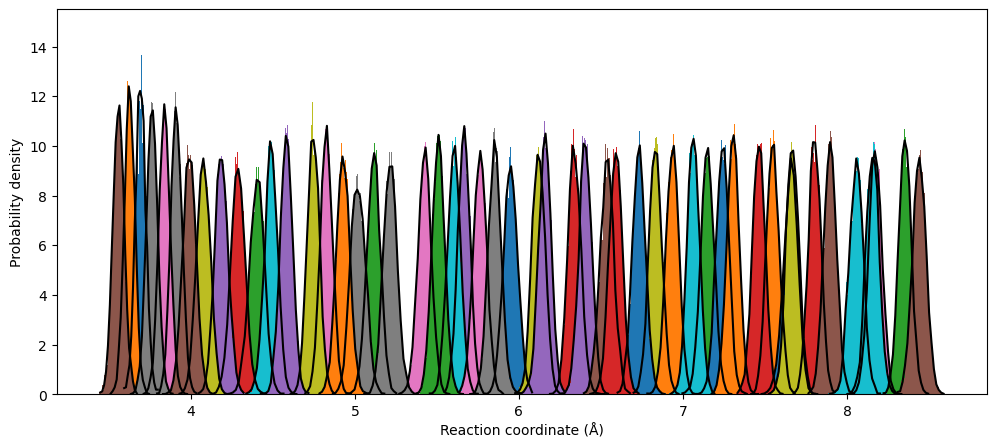

In [5]:
import glob
import numpy as np
from matplotlib import pyplot as plt

usout_list = glob.glob('../test_lasp/surface_water/data/Ru-Ru/usoutput_*',)
plt.figure(figsize=(12, 5))

for usout in usout_list:
    data = np.loadtxt(usout, skiprows=6).T
    plt.hist(data, bins=100, density=True)
    counts, bin_edges = np.histogram(data, bins=20, density=True)
    bin_centers = 0.5 * (bin_edges[1:] + bin_edges[:-1])
    plt.plot(bin_centers, counts, linestyle='-', color='k')
plt.xlabel('Reaction coordinate (Å)')
plt.ylabel('Probability density')

## RuO2 surface with Ru--Ru constraint

In [2]:
usout_list = glob.glob('../test_lasp/surface_water/data/Ru-Ru/usoutput_*',)
plt.figure(figsize=(12, 5))

for usout in usout_list:
    data = np.loadtxt(usout, skiprows=6).T
    plt.hist(data, bins=100, density=True)
    counts, bin_edges = np.histogram(data, bins=20, density=True)
    bin_centers = 0.5 * (bin_edges[1:] + bin_edges[:-1])
    plt.plot(bin_centers, counts, linestyle='-', color='k')
plt.xlabel('Reaction coordinate (Å)')
plt.ylabel('Probability density')

NameError: name 'glob' is not defined

In [38]:
with open('../test_lasp/surface_water/data/FEP.dat', 'r') as f:
    lines = f.readlines()
    read_flag = False
    fep = []
    for line in lines:
        if 'Window' in line:
            read_flag = True
        if read_flag:
            fep.append(line.split()[1])

fep = np.array(fep[1:], dtype=float)

Text(0, 0.5, 'PMF (eV)')

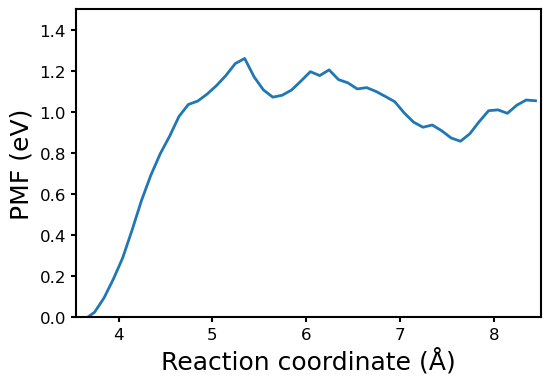

In [42]:
plt.rcParams['axes.linewidth'] = 1.5
plt.rcParams['xtick.major.width'] = 1.5
plt.rcParams['ytick.major.width'] = 1.5
plt.rcParams['xtick.labelsize'] = 'large'
plt.rcParams['ytick.labelsize'] = 'large'
plt.figure(figsize=(6, 4))
plt.plot(np.linspace(3.544, 8.444, len(fep)), fep*0.0433641, lw=2)
plt.xlim(3.544, 8.5)
plt.ylim(0, 1.5)
plt.xlabel('Reaction coordinate (Å)', fontsize=18)
plt.ylabel('PMF (eV)', fontsize=18)

## RuO2(110) surface with Ru--O constraint

Text(0, 0.5, 'Probability density')

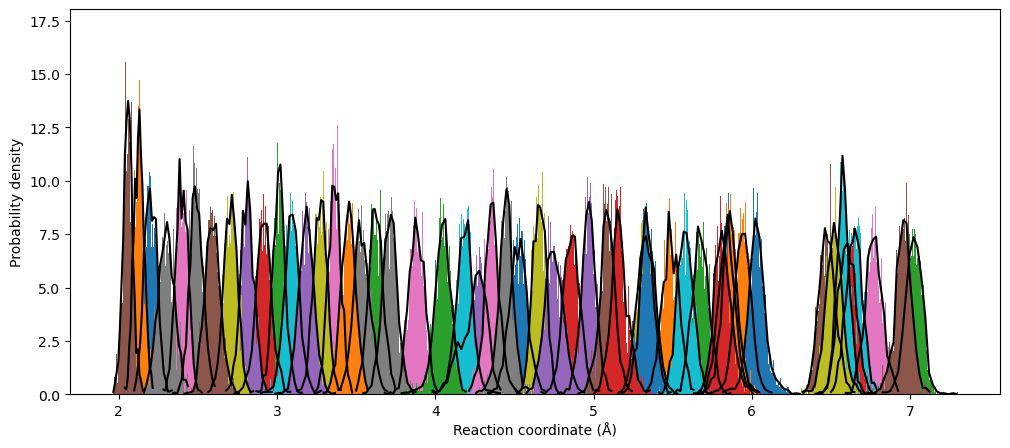

In [1]:
import glob
import numpy as np
from matplotlib import pyplot as plt

usout_list = glob.glob('../test_lasp/surface_water/data/Ru-O/usoutput_*',)
plt.figure(figsize=(12, 5))

for usout in usout_list:
    data = np.loadtxt(usout, skiprows=6).T
    plt.hist(data, bins=100, density=True)
    counts, bin_edges = np.histogram(data, bins=20, density=True)
    bin_centers = 0.5 * (bin_edges[1:] + bin_edges[:-1])
    plt.plot(bin_centers, counts, linestyle='-', color='k')
plt.xlabel('Reaction coordinate (Å)')
plt.ylabel('Probability density')

In [3]:
import numpy as np
with open('../test_lasp/surface_water/data/Ru-O/FEP.dat', 'r') as f:
    lines = f.readlines()
    read_flag = False
    fep = []
    for line in lines:
        if 'Window' in line:
            read_flag = True
        if read_flag:
            fep.append(line.split()[1])

fep = np.array(fep[1:], dtype=float)

Text(0, 0.5, 'PMF (eV)')

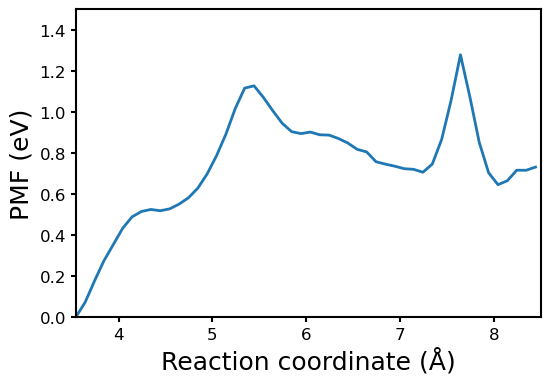

In [4]:
from matplotlib import pyplot as plt
plt.rcParams['axes.linewidth'] = 1.5
plt.rcParams['xtick.major.width'] = 1.5
plt.rcParams['ytick.major.width'] = 1.5
plt.rcParams['xtick.labelsize'] = 'large'
plt.rcParams['ytick.labelsize'] = 'large'
plt.figure(figsize=(6, 4))
plt.plot(np.linspace(3.544, 8.444, len(fep)), fep*0.0433641, lw=2)
plt.xlim(3.544, 8.5)
plt.ylim(0, 1.5)
plt.xlabel('Reaction coordinate (Å)', fontsize=18)
plt.ylabel('PMF (eV)', fontsize=18)

# IrO2 surface structure

In [ ]:
import glob
import numpy as np
from matplotlib import pyplot as plt

usout_list = glob.glob('../test_lasp/surface_water/data/Ir-Ir/usoutput_*',)
plt.figure(figsize=(12, 5))

for usout in usout_list:
    data = np.loadtxt(usout, skiprows=6).T
    plt.hist(data, bins=100, density=True)
    counts, bin_edges = np.histogram(data, bins=20, density=True)
    bin_centers = 0.5 * (bin_edges[1:] + bin_edges[:-1])
    plt.plot(bin_centers, counts, linestyle='-', color='k')
plt.xlabel('Reaction coordinate (Å)')
plt.ylabel('Probability density')

In [3]:
bulk = read('../test_lasp/bulk/IrO2.poscar')
surf = surfaces_with_termination(bulk, (1, 1, 0), layers=4, vacuum=10, termination='O')
[align_zdir(atom) for atom in surf]
#view(surf)

[Atoms(symbols='Ir2O4Ir2O4Ir2O4Ir2O4', pbc=[True, True, False], cell=[6.371475977701615, 3.17670624, 31.995408341957827], tags=...),
 Atoms(symbols='Ir2O4Ir2O4Ir2O4Ir2O4', pbc=[True, True, False], cell=[6.371475977701615, 3.17670624, 31.523854767700527], tags=...),
 Atoms(symbols='Ir2O4Ir2O4Ir2O4Ir2O4', pbc=[True, True, False], cell=[6.371475977701615, 3.17670624, 31.52385476770053], tags=...),
 Atoms(symbols='Ir2O4Ir2O4Ir2O4Ir2O4', pbc=[True, True, False], cell=[6.371475977701615, 3.17670624, 31.995408341957827], tags=...)]

In [4]:
surf_O_Ir = surf[2].repeat((2,3,1))
fix_surf = fix_layer(surf_O_Ir, 6)
fix_surf.set_pbc([True, True, True])

z_max = fix_surf.positions[:, 2].max()
grow_index = [atom.index for atom in fix_surf if (atom.position[2] > z_max - 1) and (atom.symbol == 'O')]

new_atoms, new_pos = grow_atom_BLDA(fix_surf, grow_index)
write('../test_lasp/surface_water/surf_110_Ir_sat.vasp', new_atoms)


In [5]:
water = read('../test_lasp/surface_water/water_box.pdb')
water.positions[:, 2] += fix_surf.positions[:,2].max() + 3
#fix_surf.extend(water)
new_atoms.extend(water)
write('../test_lasp/surface_water/IrO2_110/surf_110_H_sat_water.arc', new_atoms)

In [2]:
import numpy as np
with open('../test_lasp/surface_water/data/Ir-Ir/FEP.dat', 'r') as f:
    lines = f.readlines()
    read_flag = False
    fep = []
    for line in lines:
        if 'Window' in line:
            read_flag = True
        if read_flag:
            fep.append(line.split()[1])

fep = np.array(fep[1:], dtype=float)

Text(0, 0.5, 'PMF (eV)')

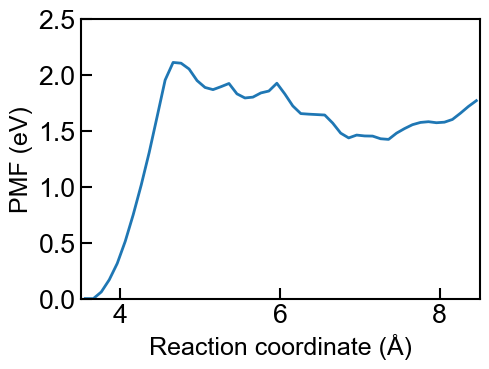

In [19]:
from matplotlib import pyplot as plt
plt.rcParams['axes.linewidth'] = 1.5
plt.rcParams['xtick.major.width'] = 1.5
plt.rcParams['ytick.major.width'] = 1.5
plt.rcParams['xtick.labelsize'] = 'large'
plt.rcParams['ytick.labelsize'] = 'large'
plt.figure(figsize=(6, 4))
plt.plot(np.linspace(3.56, 8.46, len(fep)), fep*0.0433641, lw=2)
plt.xlim(3.5, 8.5)
plt.ylim(0, 2.5)
plt.xlabel('Reaction coordinate (Å)', fontsize=18)
plt.ylabel('PMF (eV)', fontsize=18)

In [3]:
fep_Ir_Ir = read_fep('../test_lasp/surface_water/data/Ir-Ir/FEP.dat')
fep_Ru_Ru = read_fep('../test_lasp/surface_water/data/Ru-Ru/FEP.dat')
fep_Ru_O = read_fep('../test_lasp/surface_water/data/Ru-O/FEP.dat') 

Text(4.4, 2.2, '2.12 eV')

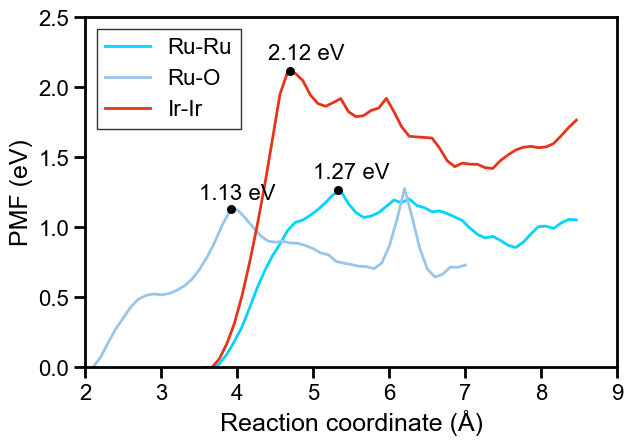

In [88]:
_plotting_config(width=8, height=5, fsize=16)

plt.plot(np.linspace(3.56, 8.46, len(fep_Ru_Ru)), fep_Ru_Ru*0.0433641, lw=2, color=clrs['azurblue'], label='Ru-Ru')
plt.plot(np.linspace(2.099, 6.999, len(fep_Ru_O)), fep_Ru_O*0.0433641, lw=2, color=clrs['lightblue'], label='Ru-O')
plt.plot(np.linspace(3.56, 8.46, len(fep_Ir_Ir)), fep_Ir_Ir*0.0433641, lw=2, color=clrs['orange2'], label='Ir-Ir')

plt.xlim(2, 9)
plt.ylim(0, 2.5)
plt.xlabel('Reaction coordinate (Å)', fontsize=18)
plt.ylabel('PMF (eV)', fontsize=18)

plt.legend()
plt.scatter([3.92], [1.13], s=30, color='k', marker='o', zorder=2)
plt.scatter([5.32], [1.27], s=30, color='k', marker='o', zorder=2)
plt.scatter([4.69], [2.12], s=30, color='k', marker='o', zorder=2)
plt.text(3.5, 1.2, '1.13 eV', fontsize=16)
plt.text(5.0, 1.35, '1.27 eV', fontsize=16)
plt.text(4.4, 2.2, '2.12 eV', fontsize=16)

#writefig('PMF_surface_water')

In [64]:
slab = [-8084.947289938028916]
slab_ch3 = [-8092.43284, -8092.41970, -8092.43279]
slab_2ch3 = [-8099.90200, -8099.90844, -8099.91417, -8099.89852]
slab_ch2 =[-8091.82098, -8091.79281, 8091.79823]
slab_ch3oh =[-8109.05603, -8109.04730, -8109.06137]
slab_oh_ch3 = [-8109.07200, -8109.08534, -8109.08924, -8109.10770]
slab_ch3_oh = [-8109.09540, -8109.05783, -8109.06144, -8109.05152]
slab_ch2ch3 = [-8099.32150, -8099.30445, -8099.31900]
ch3ch2oh = [-30.97018411640395]
ch3oh = [-24.082325464410260]
h2 = [-1.161796033125662]
h2o = [-17.219924862598557]
ch4 = [-8.075673114733515]
ch3 = [-7.392150218962773]
oh = h2o[0] - h2[0]/2
oh = -16.528484938766784
slab_oh = [-8101.60076,-8101.56888,-8101.59404,-8101.61097]

In [123]:
ads_ch3 = (slab_ch3[2] - slab[0] - ch4[0] -oh +h2o[0])
print(ads_ch3)

-0.10126687106918197


In [119]:
ads_ch3=(slab_ch3[2] - slab[0] -ch3[0])*27.2114
print(ads_ch3)

-2.5401799180320053


In [128]:
ads_oh_ch3 = (slab_oh_ch3[0] - slab_ch3[2] - oh)*27.2114
print(ads_oh_ch3)

-3.0129839312490327


In [129]:
ads_ch3oh = (slab_ch3oh[2] - slab_oh_ch3[3])*27.2114
print(ads_ch3oh)

1.2607041619786648


In [130]:
dads_ch3oh = (slab_ch3oh[0] - slab_oh_ch3[3])*27.2114
print(dads_ch3oh)

1.4060130379953988


In [132]:
ads_2ch3 = (slab_2ch3[3] - slab_ch3[2] - ch4[0] -oh +h2o[0])*27.2114
print(ads_2ch3)

-2.2176422710934425


In [133]:
ads_ch2_ch3 = (-8099.246 - slab_2ch3[3] -oh +h2o[0])*27.2114
print(ads_ch2_ch3)

-1.0590656153656903


In [134]:
ads_ch2ch3 = (slab_ch2ch3[2] - -8099.246)*27.2114
print(ads_ch2ch3)

-1.9864322000087116


In [135]:
dads = (slab[0] + ch3ch2oh[0] - slab_ch2ch3[2]-oh) *27.2114
print(dads)

-1.9045018220314955


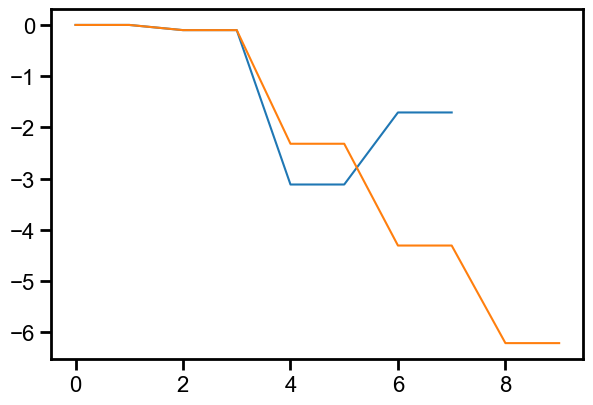

In [136]:
_plotting_config(width=8, height=5, fsize=16)
plt.plot([0, 1, 2, 3, 4, 5, 6, 7],
         [0, 0, ads_ch3, ads_ch3, ads_ch3+ads_oh_ch3, ads_ch3+ads_oh_ch3, ads_ch3+ads_oh_ch3+dads_ch3oh, ads_ch3+ads_oh_ch3+dads_ch3oh])
plt.plot([0, 1, 2, 3, 4, 5, 6, 7, 8, 9],
         [0, 0, ads_ch3, ads_ch3, ads_ch3+ads_2ch3, ads_ch3+ads_2ch3, ads_ch3+ads_2ch3+ads_ch2ch3, ads_ch3+ads_2ch3+ads_ch2ch3, ads_ch3+ads_2ch3+ads_ch2ch3+dads, ads_ch3+ads_2ch3+ads_ch2ch3+dads])

In [146]:
_plotting_config(width=8, height=5, fsize=16)
plt.plot([0, 1, 2, 3, 4, 5,],
         [0, 0, ads_oh_ch3, ads_oh_ch3, ads_oh_ch3+dads_ch3oh, ads_oh_ch3+dads_ch3oh],
         color=clrs['azurblue'], label='C1 route')
plt.plot([0, 1, 2, 3, 4, 5, 6, 7,],
         [0, 0, ads_2ch3, ads_2ch3, ads_2ch3+ads_ch2ch3, ads_2ch3+ads_ch2ch3, ads_2ch3+ads_ch2ch3+dads, ads_2ch3+ads_ch2ch3+dads],
         color=clrs['orange2'], label='C2 route')

plt.xlabel('Reaction coordinate')
plt.ylabel('Energy (eV)')
plt.legend()
writefig('adsorption_energy')

94

In [2]:
from ase.io import read
atoms = read('../test_lasp/surface_water/IrO2_110/surf_110_H_sat_water.vasp')
s  =atoms.todict()
s1 = s.copy()

In [3]:
from candidates import Candidate

In [4]:
c = Candidate(atoms)

In [6]:
import ctypes

aa = ctypes.pointer((ctypes.c_double*len(c.positions.flatten()))(*c.positions.flatten()))
aa

In [7]:
import ctypes


coords_1d = c.positions.flatten()
cell_1d = c.cell.flatten()
frac_coords_1d = c.get_scaled_positions().flatten()
bmatrix_size = len(c) ** 2
        
c_natoms = ctypes.pointer(ctypes.c_int(len(c)))
c_coords = ctypes.pointer((ctypes.c_double * len(coords_1d))(*coords_1d))
c_cell = ctypes.pointer((ctypes.c_double *len(cell_1d))(*cell_1d))
c_numbers = ctypes.pointer((ctypes.c_int *len(c))(*c.numbers))
c_frac_coords = ctypes.pointer((ctypes.c_double * len(frac_coords_1d))(*frac_coords_1d))
c_bondmatrix = ctypes.pointer((ctypes.c_int * bmatrix_size)(*[0 for i in range(bmatrix_size)]))

In [11]:
external_lib = '/Users/ychao/Library/CloudStorage/OneDrive-个人/nus/project/1_RuO2_stability/src/libs/checkminbond.so'

bcal = ctypes.cdll.LoadLibrary(external_lib)

bcal.get_all_bondmatrix_(c_natoms, c_numbers, c_coords, c_bondmatrix, c_cell)

399579400

In [21]:
s = np.array(c_bondmatrix.contents)
s

array([0, 0, 0, ..., 0, 1, 0], dtype=int32)

In [19]:
np.argwhere(ss == 1)

array([[  0, 413],
       [  1, 409],
       [  2, 410],
       ...,
       [550, 273],
       [550, 551],
       [551, 550]])

In [40]:
a = np.array([1, 2, 3, 4, 5, 6, 7, 8, 9])
b = np.random.normal(2, 1, 9)
print(a,
      b,
      np.random.choice(a, 2, p=b/b.sum()))

[1 2 3 4 5 6 7 8 9] [2.2188288  1.92078099 2.54798334 2.09282028 2.64407052 1.57615302
 2.21870888 1.4300958  1.85710827] [1 5]


In [53]:
datetime.now().strftime('%Y-%m-%d')

'2024-11-24'

In [56]:
c.add_metadata('Parent',1)

In [57]:
s =c.copy()

In [58]:
s.metadata

{'Parent': 1}

In [68]:
from ase.build import molecule

CO =molecule('CO')
atoms.append

Signature: atoms.append(atom)
Source:   
    def append(self, atom):
        """Append atom to end."""
        self.extend(self.__class__([atom]))
File:      ~/Documents/develops/ase/ase/atoms.py
Type:      method

In [75]:
c.append(CO[0])

AttributeError: 'list' object has no attribute 'todict'

In [81]:
CO.__class__([CO[0]])

Atoms(symbols='O', pbc=False)

In [79]:
CO[0].__class__

ase.atom.Atom

In [87]:
atoms.todict()

{'numbers': array([ 1,  1,  1,  1,  1,  1,  1,  1,  1,  1,  1,  1,  1,  1,  1,  1,  1,
         1,  1,  1,  1,  1,  1,  1,  1,  1,  1,  1,  1,  1,  1,  1,  1,  1,
         1,  1,  1,  1,  1,  1,  1,  1,  1,  1,  1,  1,  1,  1,  1,  1,  1,
         1,  1,  1,  1,  1,  1,  1,  1,  1,  1,  1,  1,  1,  1,  1,  1,  1,
         1,  1,  1,  1,  1,  1,  1,  1,  1,  1,  1,  1,  1,  1,  1,  1,  1,
         1,  1,  1,  1,  1,  1,  1,  1,  1,  1,  1,  1,  1,  1,  1,  1,  1,
         1,  1,  1,  1,  1,  1,  1,  1,  1,  1,  1,  1,  1,  1,  1,  1,  1,
         1,  1,  1,  1,  1,  1,  1,  1,  1,  1,  1,  1,  1,  1,  1,  1,  1,
         1,  1,  1,  1,  1,  1,  1,  1,  1,  1,  1,  1,  1,  1,  1,  1,  1,
         1,  1,  1,  1,  1,  1,  1,  1,  1,  1,  1,  1,  1,  1,  1,  1,  1,
         1,  1,  1,  1,  1,  1,  1,  1,  1,  1,  1,  1,  1,  1,  1,  1,  1,
         1,  1,  1,  1,  1,  1,  1,  1,  1,  1,  1,  1,  1,  1,  1,  1,  1,
         1,  1,  1,  1,  1,  1,  1,  1,  1,  1,  1,  1,  1,  1,  1,  1,  1,
 

In [ ]:
from ase import Atom, Atoms
ads = Atoms([Atom('O', position=[0, 0, 0])

In [114]:
ads_1 = Atom('Ru', position=[0, 0, 0])
ads_2 = Atom('O', position=[0, 0, 0])
ads = np.random.choice([ads_1, ads_2], 1)

In [118]:
ads_1 = Atoms([Atom('Ru', position=[0, 0, 0])])
ads_2 = Atoms([Atom('O', position=[0, 0, 0])])
ads_3 = Atoms([Atom('H', position=[0, 0, 0])])
ads = np.random.choice([1,2,3], 1, [0.5, 0.25, 0.25])

In [119]:
ads

array([2])

In [77]:
c = Candidate(surf_O_Ru_1)
c1 = Candidate(surf_O_Ru_2)

In [78]:
c.get_identifier() == c1.get_identifier()


ValueError: operands could not be broadcast together with shapes (12,) (24,) 

In [83]:
for a, b in zip(c.get_identifier(), c1.get_identifier()):
    if len(a) != len(b):
        print(a, b)

[44 44  8  8  8  8 44 44  8  8  8  8] [44 44  8  8  8  8 44 44  8  8  8  8 44 44  8  8  8  8 44 44  8  8  8  8]
[[ 2.24125016e+00  1.55567070e+00  2.24126016e+00]
 [-2.31184559e-32 -3.45428286e-16  1.00000000e-05]
 [ 3.61039474e+00  1.55567070e+00  8.72115579e-01]
 [ 8.72105579e-01  1.55567070e+00  3.61040474e+00]
 [ 3.11335574e+00  0.00000000e+00  3.11336574e+00]
 [ 1.36914458e+00 -3.45428286e-16  1.36915458e+00]
 [ 2.24125016e+00  1.55567070e+00  6.72376047e+00]
 [ 7.00000004e-16  0.00000000e+00  4.48251031e+00]
 [ 3.61039474e+00  1.55567070e+00  5.35461589e+00]
 [ 8.72105579e-01  1.55567070e+00  8.09290505e+00]
 [ 3.11335574e+00  1.62939083e-16  7.59586605e+00]
 [ 1.36914458e+00  4.62043555e-17  5.85165489e+00]] [[5.48994984e+00 3.91782324e+00 1.11019188e+00]
 [2.76170616e+00 1.97085162e+00 1.00000000e-05]
 [2.59108190e+00 3.33893722e-01 1.11019188e+00]
 [1.15821373e+00 2.34173683e+00 1.11019188e+00]
 [7.09344227e+00 5.06213240e+00 8.63988352e-01]
 [3.88645741e+00 2.77351408e+00 1.3

In [81]:
c1.get_identifier()

(array([44, 44,  8,  8,  8,  8, 44, 44,  8,  8,  8,  8, 44, 44,  8,  8,  8,
         8, 44, 44,  8,  8,  8,  8]),
 array([[5.48994984e+00, 3.91782324e+00, 1.11019188e+00],
        [2.76170616e+00, 1.97085162e+00, 1.00000000e-05],
        [2.59108190e+00, 3.33893722e-01, 1.11019188e+00],
        [1.15821373e+00, 2.34173683e+00, 1.11019188e+00],
        [7.09344227e+00, 5.06213240e+00, 8.63988352e-01],
        [3.88645741e+00, 2.77351408e+00, 1.35639540e+00],
        [3.71583315e+00, 2.65175054e+00, 3.33055563e+00],
        [9.87589465e-01, 7.04778927e-01, 2.22037375e+00],
        [2.59108190e+00, 4.22783695e+00, 3.33055563e+00],
        [4.84058440e+00, 1.07566413e+00, 3.33055563e+00],
        [5.31932558e+00, 3.79605970e+00, 3.08435211e+00],
        [2.11234072e+00, 1.50744138e+00, 3.57675916e+00],
        [1.94171646e+00, 1.38567784e+00, 5.55091939e+00],
        [6.44407683e+00, 4.59872216e+00, 4.44073751e+00],
        [6.27345257e+00, 2.96176425e+00, 5.55091939e+00],
        [4.84058

In [93]:
for i in range(10):
    seed = range(9000, 9000+20)
    np.random.seed(seed[i])
    attempt = np.max( [10, np.ceil(50/10)])

In [97]:
c = Candidate(surf_O_Ru_1)
c.todict()

{'numbers': array([44, 44,  8,  8,  8,  8, 44, 44,  8,  8,  8,  8]),
 'positions': array([[ 2.24125016e+00,  1.55567070e+00,  2.24126016e+00],
        [-2.31184559e-32, -3.45428286e-16,  1.00000000e-05],
        [ 3.61039474e+00,  1.55567070e+00,  8.72115579e-01],
        [ 8.72105579e-01,  1.55567070e+00,  3.61040474e+00],
        [ 3.11335574e+00,  0.00000000e+00,  3.11336574e+00],
        [ 1.36914458e+00, -3.45428286e-16,  1.36915458e+00],
        [ 2.24125016e+00,  1.55567070e+00,  6.72376047e+00],
        [ 7.00000004e-16,  0.00000000e+00,  4.48251031e+00],
        [ 3.61039474e+00,  1.55567070e+00,  5.35461589e+00],
        [ 8.72105579e-01,  1.55567070e+00,  8.09290505e+00],
        [ 3.11335574e+00,  1.62939083e-16,  7.59586605e+00],
        [ 1.36914458e+00,  4.62043555e-17,  5.85165489e+00]]),
 'tags': array([2, 2, 2, 2, 2, 2, 1, 1, 1, 1, 1, 1]),
 'cell': array([[4.48250032e+00, 0.00000000e+00, 0.00000000e+00],
        [2.08232539e-16, 3.11134140e+00, 0.00000000e+00],
      

In [98]:
c.append(Atom('O', position=[0, 0, 0]))
c.todict()

{'numbers': array([44, 44,  8,  8,  8,  8, 44, 44,  8,  8,  8,  8,  8]),
 'positions': array([[ 2.24125016e+00,  1.55567070e+00,  2.24126016e+00],
        [-2.31184559e-32, -3.45428286e-16,  1.00000000e-05],
        [ 3.61039474e+00,  1.55567070e+00,  8.72115579e-01],
        [ 8.72105579e-01,  1.55567070e+00,  3.61040474e+00],
        [ 3.11335574e+00,  0.00000000e+00,  3.11336574e+00],
        [ 1.36914458e+00, -3.45428286e-16,  1.36915458e+00],
        [ 2.24125016e+00,  1.55567070e+00,  6.72376047e+00],
        [ 7.00000004e-16,  0.00000000e+00,  4.48251031e+00],
        [ 3.61039474e+00,  1.55567070e+00,  5.35461589e+00],
        [ 8.72105579e-01,  1.55567070e+00,  8.09290505e+00],
        [ 3.11335574e+00,  1.62939083e-16,  7.59586605e+00],
        [ 1.36914458e+00,  4.62043555e-17,  5.85165489e+00],
        [ 0.00000000e+00,  0.00000000e+00,  0.00000000e+00]]),
 'tags': array([2, 2, 2, 2, 2, 2, 1, 1, 1, 1, 1, 1, 0]),
 'cell': array([[4.48250032e+00, 0.00000000e+00, 0.00000000e+0

In [145]:
tt=[]
for i in range(20):
    atom = db.get_atoms(id=i+1)
    c = Candidate(atom)

In [129]:
task_type = ["reconstruction", "growth", "dissolution"]
t =  []
for i in range(100):
    task = np.random.choice(task_type, p=[0.8, 0.1, 0.1])
    t.append(task)
print(t.count('reconstruction'), t.count('growth'), t.count('dissolution'))

79 10 11


In [117]:
elements = ['a', 'b', 'c']
results = []
probabilities = [0.1, 0.3, 0.6]  # 确保 sum(probabilities) == 1
for i in range(100):
    results.append(np.random.choice(elements, p=probabilities))
print(results.count('a'), results.count('b'), results.count('c'))

10 33 57


In [139]:
c.numbers, c.constraints

(array([44, 44,  8,  8,  8,  8, 44, 44,  8,  8,  8,  8, 44, 44,  8,  8,  8,
         8, 44, 44,  8,  8,  8,  8, 44, 44,  8,  8,  8, 44, 44,  8,  8,  8,
         8, 44, 44,  8,  8,  8,  8, 44, 44,  8,  8,  8,  8]),
 [FixAtoms(indices=[0, 1, 2, 3, 4, 5, 12, 13, 14, 15, 16, 17, 24, 25, 26, 27, 28, 35, 36, 37, 38, 39, 40])])

In [143]:
c.pop(12)
c.numbers, c.constraints

(array([44, 44,  8,  8,  8,  8, 44, 44,  8,  8,  8,  8, 44,  8,  8,  8,  8,
        44, 44,  8,  8,  8, 44, 44,  8,  8,  8, 44, 44,  8,  8,  8,  8, 44,
        44,  8,  8,  8,  8, 44, 44,  8,  8,  8,  8]),
 [FixAtoms(indices=[0, 1, 2, 3, 4, 5, 12, 13, 14, 15, 16, 22, 23, 24, 25, 26, 33, 34, 35, 36, 37, 38])])

In [26]:
c.todict()

{'numbers': array([44, 44,  8,  8,  8,  8, 44, 44,  8,  8,  8,  8, 44, 44,  8,  8,  8,
         8, 44, 44,  8,  8,  8,  8, 44, 44,  8,  8,  8,  8, 44, 44,  8,  8,
         8,  8, 44, 44,  8,  8,  8,  8, 44, 44,  8,  8,  8,  8]),
 'positions': array([[ 3.16960637e+00,  1.55567070e+00,  1.00000000e-05],
        [ 0.00000000e+00,  0.00000000e+00,  1.00000000e-05],
        [ 1.23334354e+00,  1.55567070e+00,  1.00000000e-05],
        [ 5.10586920e+00,  1.55567070e+00,  1.00000000e-05],
        [ 3.16960637e+00,  0.00000000e+00,  1.23335354e+00],
        [-7.03793994e-16, -3.45428286e-16,  1.93627283e+00],
        [ 0.00000000e+00,  1.55567070e+00,  3.16961637e+00],
        [ 3.16960637e+00, -3.45428286e-16,  3.16961637e+00],
        [ 4.40294991e+00,  1.55567070e+00,  3.16961637e+00],
        [ 1.93626283e+00,  1.55567070e+00,  3.16961637e+00],
        [-7.03793994e-16, -3.45428286e-16,  4.40295991e+00],
        [ 3.16960637e+00, -3.45428286e-16,  5.10587920e+00],
        [ 3.16960637e+00, 

In [8]:
qqq = q.todict()
type(c.candidate2atoms())

ase.atoms.Atoms

In [52]:
import sys
sys.path.insert(0, '/Users/ychao/Documents/develops/ase/')
from ase.db import connect
db = connect('/Users/ychao/Library/CloudStorage/OneDrive-个人/nus/project/1_RuO2_stability/src/test/dateset/candidates_surf.db')
from candidates import Candidate
tt = []
q=db.get_atoms(id=2)
c = Candidate(q)
#for i in range(len(c)):
#    #pp = c.candidate2atoms()
#    pp = c.copy()
#    pp.delete(i)
#    tt.append(pp)
#from ase.visualize import view
#view(tt)

In [8]:
print(c.constraints)
c.pop(4)
print(c.constraints)

[FixAtoms(indices=[0, 1, 2, 3, 4, 5, 12, 13, 14, 15, 16, 17])]
[FixAtoms(indices=[0, 1, 2, 3, 4, 11, 12, 13, 14, 15, 16])]


In [10]:
print(c.constraints)
c.delete(8)
print(c.constraints)

[FixAtoms(indices=[0, 1, 2, 3, 9, 10, 11, 12, 13, 14])]
[FixAtoms(indices=[0, 1, 2, 3, 8, 9, 10, 11, 12])]


In [ ]:
tt = []
for i in c:
    if i.index == 3:
        pass
    tt.append(i)
    

In [29]:
c.todict()
import numpy as np
from ase.constraints import FixAtoms
iii = 3
new_dict = {}
for k, v in c.todict().items():
    if k == 'numbers' or k == 'positions':
        np.delete(v, iii)
    elif k == 'constraints':
        constraints = list(v[0].index)
        if iii in constraints:
            constraints.remove(iii)
        labels = [ i -1 if i > iii else i for i in constraints]
        k = 'constraint'
        v = FixAtoms(labels)
    else:
        pass
    new_dict.setdefault(k, v)

In [30]:
new_dict

{'numbers': array([44, 44,  8,  8,  8,  8, 44, 44,  8,  8,  8,  8, 44, 44,  8,  8,  8,
         8, 44, 44,  8,  8,  8,  8, 44, 44,  8,  8,  8,  8, 44, 44,  8,  8,
         8,  8, 44, 44,  8,  8,  8,  8, 44, 44,  8,  8,  8,  8]),
 'positions': array([[ 3.16960637e+00,  1.55567070e+00,  1.00000000e-05],
        [ 0.00000000e+00,  0.00000000e+00,  1.00000000e-05],
        [ 1.23334354e+00,  1.55567070e+00,  1.00000000e-05],
        [ 5.10586920e+00,  1.55567070e+00,  1.00000000e-05],
        [ 3.16960637e+00,  0.00000000e+00,  1.23335354e+00],
        [-7.03793994e-16, -3.45428286e-16,  1.93627283e+00],
        [ 0.00000000e+00,  1.55567070e+00,  3.16961637e+00],
        [ 3.16960637e+00, -3.45428286e-16,  3.16961637e+00],
        [ 4.40294991e+00,  1.55567070e+00,  3.16961637e+00],
        [ 1.93626283e+00,  1.55567070e+00,  3.16961637e+00],
        [-7.03793994e-16, -3.45428286e-16,  4.40295991e+00],
        [ 3.16960637e+00, -3.45428286e-16,  5.10587920e+00],
        [ 3.16960637e+00, 

In [31]:
view(Candidate(Atoms(**new_dict)))

<Popen: returncode: None args: ['/Users/ychao/Documents/conda/env/ase/bin/py...>

(array([44, 44,  8,  8,  8, 44, 44,  8,  8,  8,  8, 44, 44,  8,  8,  8,  8,
        44, 44,  8,  8,  8,  8, 44, 44,  8,  8,  8,  8, 44, 44,  8,  8,  8,
         8, 44, 44,  8,  8,  8,  8, 44, 44,  8,  8,  8,  8]),
 [FixAtoms(indices=[0, 1, 2, 3, 4, 5, 6, 7, 20, 21, 22, 23, 24, 25, 26, 27, 28, 29, 30, 31])])

In [32]:
c

Candidate(symbols='Ru2O4Ru2O4Ru2O4Ru2O4Ru2O4Ru2O4Ru2O4Ru2O4', pbc=True, cell=[6.339212738814671, 6.2226828, 31.445081939865076], tags=..., constraint=FixAtoms(indices=[0, 1, 2, 3, 4, 5, 12, 13, 14, 15, 16, 17]))

In [53]:
z = list(c.positions[:,2])
n = list(c.numbers)
const = list(c.constraints[0].index)
z_index = sorted(range(len(z)), key=lambda k:(z[k], -n[k]))


In [54]:
c.constraints, z_index, 

([FixAtoms(indices=[0, 1, 2, 3, 4, 5, 6, 7, 8, 9, 10, 11, 24, 25, 26, 27, 28, 29, 30, 31, 32, 33, 34, 35])],
 [0,
  1,
  24,
  25,
  2,
  3,
  26,
  27,
  4,
  28,
  5,
  29,
  7,
  31,
  8,
  9,
  32,
  33,
  6,
  30,
  10,
  34,
  11,
  35,
  13,
  37,
  15,
  39,
  12,
  36,
  14,
  38,
  16,
  40,
  17,
  41,
  18,
  19,
  42,
  43,
  20,
  21,
  44,
  45,
  22,
  46,
  23,
  47])

In [56]:
for i in const:
    print(z_index.index(i))

0
1
4
5
8
10
18
12
14
15
20
22
2
3
6
7
9
11
19
13
16
17
21
23


In [64]:
nn = {'positions':[],
      'numbers':[],
      'pbc':[],
      'cell':[],
      'constraint':[]}
for i in range(len(c)):
    nn['positions'].append(c.positions[z_index[i]])
    nn['numbers'].append(c.numbers[z_index[i]])

In [69]:
nn['cell'] = c.cell
nn['pbc'] = c.pbc
view(Atoms(**nn))

<Popen: returncode: None args: ['/Users/ychao/Documents/conda/env/ase/bin/py...>

2024-11-26 17:53:11.118 python[52353:4154240] +[IMKClient subclass]: chose IMKClient_Modern
2024-11-26 17:53:11.118 python[52353:4154240] +[IMKInputSession subclass]: chose IMKInputSession_Modern


[FixAtoms(indices=[0, 1, 2, 3, 4, 5, 6, 7, 8, 9, 10, 11, 24, 25, 26, 27, 28, 29, 30, 31, 32, 33, 34, 35])]